# Génération de formes à partir des règles
 - Génération : génération des formes d'après les contextes phonologiques
 - Filtrage : extraction du paradigme
- Évaluation  

## Importations
- codecs pour les encodages
- pandas et numpy pour les calculs sur tableaux
- matplotlib pour les graphiques
- itertools pour les itérateurs sophistiqués (paires sur liste, ...)

In [2]:
# -*- coding: utf8 -*-
import codecs,operator,datetime,os,glob
import features
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import itertools as it
import pickle
import networkx as nx
from scipy.stats import entropy
import seaborn as sns
import math

sns.set_style("whitegrid")
# Define the colormap for heatmaps
colors = [(0, 1, 0), (1, .5, 0), (1, 0, 0)]  # Green -> White -> Red
n_bins = 100  # Discretize the interpolation into bins
cmap_name = 'green_red'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)


#%pylab inline
#pd.options.display.mpl_style = 'default'
debug=False
from __future__ import print_function

def ding():
    os.system('afplay /System/Library/Sounds/Submarine.aiff')

In [2]:
%matplotlib inline
%store -r cellOrd
# ordStemCells

In [3]:
import yaml

In [4]:
from IPython.display import display, HTML

In [5]:
import datetime
def dateheure():
    return datetime.datetime.utcnow().strftime('%y%m%d%H%M')

In [6]:
saut="\n"

### Préparation des matrices de traits

In [7]:
features.add_config('/Users/gilles/Github/SWIM/ParadigmGeneration/Vlexique2/bdlexique.ini')
fs=features.FeatureSystem('phonemes')

# Choix de l'échantillon et des règles
- *sampleFile* est le nom de l'échantillon de départ
- *rulesFile* est le nom du fichier de règles
- *goldFile* est le nom du lexique Gold de référence

In [4]:
repFiles="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"
rulesFile="vlexique2-Total-Regles.pkl"
fRules=repFiles+rulesFile

# Préparation du calcul des analogies

### Calcul de la différence entre deux formes

In [9]:
def diff(mot1,mot2):
    result=[]
    diff1=""
    diff2=""
    same=""
    vide="."
    lmax=max(len(mot1),len(mot2))
    lmin=min(len(mot1),len(mot2))
    for index in range(lmax):
        if index < lmin:
            if mot1[index]!=mot2[index]:
                diff1+=mot1[index]
                diff2+=mot2[index]
                same+=vide
            else:
                same+=mot1[index]
                diff1+=vide
                diff2+=vide
        elif index < len(mot1):
            diff1+=mot1[index]
        elif index < len(mot2):
            diff2+=mot2[index]
    diff1=diff1.lstrip(".")
    diff2=diff2.lstrip(".")
#    return (same,diff1,diff2,diff1+"_"+diff2)
    return (diff1+"-"+diff2)

### Accumulation des paires appartenant à un patron

In [10]:
def rowDiff(row, patrons):
    result=diff(row[0],row[1])
    if not result in patrons:
        patrons[result]=(formesPatron(),formesPatron())
    patrons[result][0].ajouterFormes(row[0])
    patrons[result][1].ajouterFormes(row[1])
    return (result[0],result[1])

### Transformation d'un patron en RegExp

In [11]:
def patron2regexp(morceaux):
    result="^"
    for morceau in morceaux:
        if morceau=="*":
            result+="(.*)"
        elif len(morceau)>1:
            result+="(["+morceau+"])"
        else:
            result+=morceau
    result+="$"
    result=result.replace(")(","")
    return result

### Substitution de sortie 
???

In [12]:
def remplacementSortie(sortie):
    n=1
    nsortie=""
    for lettre in sortie:
        if lettre==".":
            nsortie+="\g<%d>"%n
            n+=1
        else:
            nsortie+=lettre
    return nsortie

# Classe pour la gestion des patrons, des classes et des transformations

In [13]:
class paireClasses:
    def __init__(self,case1,case2):
        self.case1=case1
        self.case2=case2
        self.nom=case1+"-"+case2
        self.classes1=classesPaire(case1,case2)
        self.classes2=classesPaire(case2,case1)

    def ajouterPatron(self,n,patron,motif):
        if n==1:
            self.classes1.ajouterPatron(patron,motif)
        elif n==2:
            self.classes2.ajouterPatron(patron,motif)
        else:
            if debug: print ("le numéro de forme n'est pas dans [1,2]",n, file=logfile)

    def ajouterPaire(self,forme1,forme2):
        self.classes1.ajouterPaire(forme1,forme2)
        self.classes2.ajouterPaire(forme2,forme1)
        
    def calculerClasses(self):
        return(self.classes1,self.classes2)

    
class classesPaire:
    '''
    Gestion des patrons, des classes et des transformations
    
    ajouterPatron : ajoute un patron et son motif associé (MGL)
    ajouterPaire : ajoute une paire de formes, calcule la classe de la forme1 et la règle sélectionnée
    sortirForme : cacule les formes de sortie correspondant à la forme1 avec leurs coefficients respectifs
    '''
    def __init__(self,case1,case2):
        self.case1=case1
        self.case2=case2
        self.nom=case1+"-"+case2
        self.classe={}
        self.nbClasse={}
        self.patrons={}
        self.entree={}
        self.sortie={}
        self.classeCF={}
        self.nbClasseCF={}
    
    def ajouterPatron(self,patron,motif):
        self.patrons[patron]=motif
        (entree,sortie)=patron.split("-")
        self.entree[patron]=entree.replace(u".",u"(.)")
        self.sortie[patron]=remplacementSortie(sortie)
    
    def ajouterPaire(self,forme1,forme2):
        '''
        on calcule la classe de la paire idClasseForme et la règle sélectionnée
        on incrémente le compteur de la classe et celui de la règle sélectionnée à l'intérieur de la classe
        '''
        classeFormeCF=[]
        regleFormeCF=""
        classeForme=[]
        regleForme=""
        for patron in self.patrons:
            filterF1=".*"+patron.split("-")[0]+"$"
            if re.match(filterF1,forme1):
                classeFormeCF.append(patron)
                if forme2==re.sub(self.entree[patron]+"$",self.sortie[patron],forme1):
                    regleFormeCF=patron
            filterF1=self.patrons[patron]
            if re.match(filterF1,forme1):
                classeForme.append(patron)
                '''
                le +"$" permet de forcer l'alignement à droite pour les transformations suffixales
                '''
                if forme2==re.sub(self.entree[patron]+"$",self.sortie[patron],forme1):
                    regleForme=patron
        idClasseFormeCF=", ".join(classeFormeCF)
        if not idClasseFormeCF in self.classeCF:
            self.classeCF[idClasseFormeCF]={}
            self.nbClasseCF[idClasseFormeCF]=0
        if not regleFormeCF in self.classeCF[idClasseFormeCF]:
            self.classeCF[idClasseFormeCF][regleFormeCF]=0
        self.nbClasseCF[idClasseFormeCF]+=1
        self.classeCF[idClasseFormeCF][regleFormeCF]+=1
        
        idClasseForme=", ".join(classeForme)
        if not idClasseForme in self.classe:
            self.classe[idClasseForme]={}
            self.nbClasse[idClasseForme]=0
        if not regleForme in self.classe[idClasseForme]:
            self.classe[idClasseForme][regleForme]=0
        self.nbClasse[idClasseForme]+=1
        self.classe[idClasseForme][regleForme]+=1

    def sortirForme(self,forme,contextFree=True):
        classeForme=[]
        sortieForme={}
        for patron in self.patrons:
            if contextFree:
                filterF1=".*"+patron.split("-")[0]+"$"
            else:
                filterF1=self.patrons[patron]
            if re.match(filterF1,forme):
                classeForme.append(patron)
        if classeForme:
            idClasseForme=", ".join(classeForme)
            if contextFree:
                nbClasse=self.nbClasseCF
                classe=self.classeCF
            else:
                nbClasse=self.nbClasse
                classe=self.classe
            if idClasseForme in nbClasse:
                nTotal=nbClasse[idClasseForme]
                for patron in classe[idClasseForme]:
                    sortie=re.sub(self.entree[patron]+"$",self.sortie[patron],forme)
                    sortieForme[sortie]=float(classe[idClasseForme][patron])/nTotal
            else:
                if debug:
                    print (forme, file=logfile)
                    print ("pas de classe",idClasseForme, file=logfile)
                    print ("%.2f par forme de sortie" % (float(1)/len(classeForme)), file=logfile)
                nTotal=len(classeForme)
                for patron in classeForme:
                    sortie=re.sub(self.entree[patron]+"$",self.sortie[patron],forme)
                    sortieForme[sortie]=float(1)/nTotal
        else:
            if debug:
                print (forme, file=logfile) 
                print ("pas de patron", file=logfile)
        return sortieForme
        

## Appliquer la formule de calcul des différences entre chaines à chaque ligne

>si il y a au moins une ligne

>>on applique la différence à la ligne

>>on calcule les deux patrons par suppression des points initiaux

>>on renvoie le groupement par patrons (1&2)

>sinon

>>on renvoie le paradigme vide d'origine

In [14]:
def rapports(paradigme):
    if len(paradigme.columns.values.tolist())==2:
        (case1,lexeme)= paradigme.columns.values.tolist()
        case2=case1
    else:
        (case1,case2,lexeme)= paradigme.columns.values.tolist()
    patrons=pairePatrons(case1,case2)
    classes=paireClasses(case1,case2)
    if len(paradigme)>0:
        paradigme.apply(lambda x: patrons.ajouterFormes(x[case1],x[case2],diff(x[case1],x[case2])), axis=1)
        (regles1,regles2)=patrons.calculerGM()
        for regle in regles1:
            classes.ajouterPatron(1,regle,regles1[regle])
        for regle in regles2:
            classes.ajouterPatron(2,regle,regles2[regle])
        paradigme.apply(lambda x: classes.ajouterPaire(x[case1],x[case2]), axis=1)
    (classes1,classes2)=classes.calculerClasses()
    return (classes1,classes2)

### Dédoubler les lignes avec des surabondances dans *colonne*
>identifier une ligne avec surabondance

>>ajouter les lignes correspondant à chaque valeur

>>ajouter le numéro de la ligne initiale dans les lignes à supprimer

>supprimer les lignes avec surabondance

NB : il faut préparer le tableau pour avoir une indexation qui permette l'ajout des valeurs individuelles et la suppression des lignes de surabondances

In [15]:
def splitCellMates(df,colonne):
    '''
    Calcul d'une dataframe sans surabondance par dédoublement des valeurs
    '''
    test=df.reset_index()
    del test["index"]
    splitIndexes=[]
    for index,ligne in test.iterrows():
        if "," in ligne[colonne]:
            valeurs=set(ligne[colonne].split(","))
            nouvelleLigne=ligne
            for valeur in valeurs:
                nouvelleLigne[colonne]=valeur
                test=test.append(nouvelleLigne,ignore_index=True)
            splitIndexes.append(index)
    if splitIndexes:
        test=test.drop(test.index[splitIndexes])
    return test


# Lecture de l'échantillon

## Préparation des données initiales et de référence

# Lecture des règles

In [16]:
results={}

In [17]:
def makeTable(lEntropie):
    # print(lEntropie)
    dfE=pd.DataFrame(lEntropies)
    dfE[["predictor","predicted"]]=pd.DataFrame(dfE[0].tolist(), index=dfE.index)
    dfE[["nb","entropy"]]=pd.DataFrame(dfE[1].tolist(), index=dfE.index)
    dfE.predictor=pd.Categorical(dfE.predictor,categories=cellOrd)
    dfE.predicted=pd.Categorical(dfE.predicted,categories=cellOrd)
    display(dfE.sort_values(["predictor","predicted"],inplace=True))
    dfE=dfE.pivot(index="predictor",columns="predicted",values=["nb","entropy"])
    return dfE

In [18]:
def cumulateEntropy(lCF):
    # print(tCF)
    # lCF=[d for p,d in tCF]
    # print(lCF)
    entropie=0
    total=sum([n for n,e in lCF])
    if total==0:
        return 0,0
    for tot,ent in lCF:
        # print(tot,ent,"%.2f%%"%(tot/total*100),ent*tot/total)
        entropie+=tot/total*ent
    # print(total, entropie)
    return total,entropie

def calculateEntropy(paire,dCF):
    total=0.0
    entropies=[]
    for k,v in dCF.items():
        dist=list(v.values())
        distTot=sum(dist)
        total+=distTot
        distEnt=entropy(dist,base=2)
        entropies.append((distTot,distEnt))
    return cumulateEntropy(entropies)

In [19]:
def sampleEntropy(regles):
    entropies=[]
    nbPaires=0
    for paire,cPaire in regles.items():
        # print(paire,end=": ")
        nbPaires+=1
        dictCF=cPaire.classeCF
        entropies.append((paire,calculateEntropy(paire,dictCF)))
    return entropies

None

0.9911459178042564


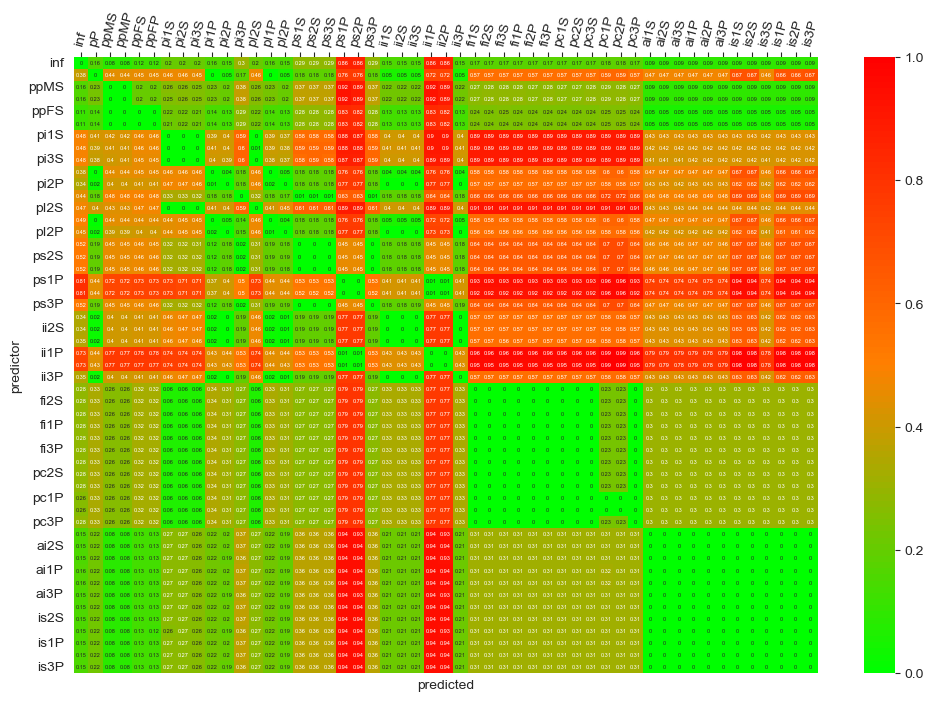

In [20]:
rulesFile="vlexique2-Total-filtre-Regles.pkl"
fRules=repFiles+rulesFile
with open(fRules, 'rb') as input:
    resultatsLecture = pickle.load(input)
# resultatsLecture[('fi1P', 'ai1P')].classeCF 

lEntropies=sampleEntropy(resultatsLecture)
dfE=makeTable(lEntropies)
# display(dfE.loc[:,"entropy"].round(decimals=4))
with pd.ExcelWriter(repFiles+"entropies.xlsx",engine="openpyxl") as writer:
    dfE.loc[:,"entropy"].round(decimals=4).to_excel(writer, sheet_name="Total-Simplifié")

print(dfE.loc[:,"entropy"].max().max())

plt.figure(figsize = (12,8))
ax=sns.heatmap(dfE.loc[:,"entropy"].round(decimals=2),annot=True,annot_kws={"fontsize":4},cmap=cm,vmin=0,vmax=1)
ax.xaxis.tick_top()
ax.tick_params(axis='x', labelrotation=75)

plt.savefig(repFiles+"HM-Entropy-Total-filtre.png",dpi=300,bbox_inches="tight")
plt.show()

None

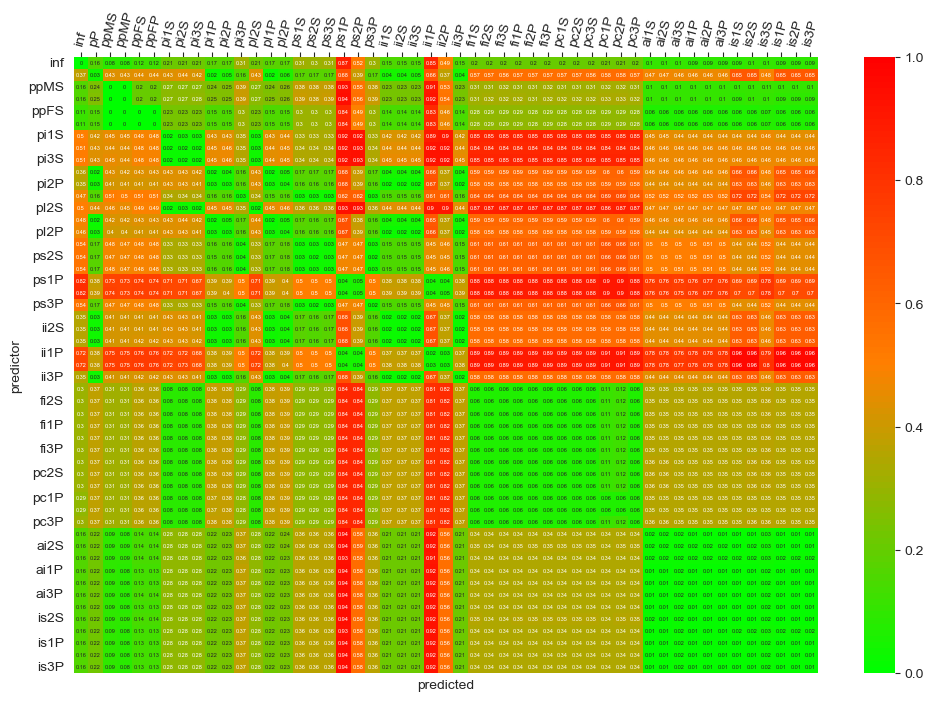

In [21]:
rulesFile="vlexique2-Total-Regles.pkl"
fRules=repFiles+rulesFile
with open(fRules, 'rb') as input:
    resultatsLecture = pickle.load(input)
# resultatsLecture[('fi1P', 'ai1P')].classeCF 

lEntropies=sampleEntropy(resultatsLecture)
dfE=makeTable(lEntropies)
# display(dfE.loc[:,"entropy"].round(decimals=4))
with pd.ExcelWriter(repFiles+"entropies.xlsx",engine="openpyxl",mode="a") as writer:
    dfE.loc[:,"entropy"].round(decimals=4).to_excel(writer, sheet_name="Total")
    
plt.figure(figsize = (12,8))
ax=sns.heatmap(dfE.loc[:,"entropy"].round(decimals=2),annot=True,annot_kws={"fontsize":4},cmap=cm,vmin=0,vmax=1)
ax.xaxis.tick_top()
ax.tick_params(axis='x', labelrotation=75)

plt.savefig(repFiles+"HM-Entropy-Total.png",dpi=300,bbox_inches="tight")
plt.show()

In [111]:
results[-1]=dfE.loc[:,"entropy"].mean().mean()
print(dfE.loc[:,"entropy"].max().max())
results[-1]

0.9592610322976362


0.3544543256271373

None

1.5304808577552238


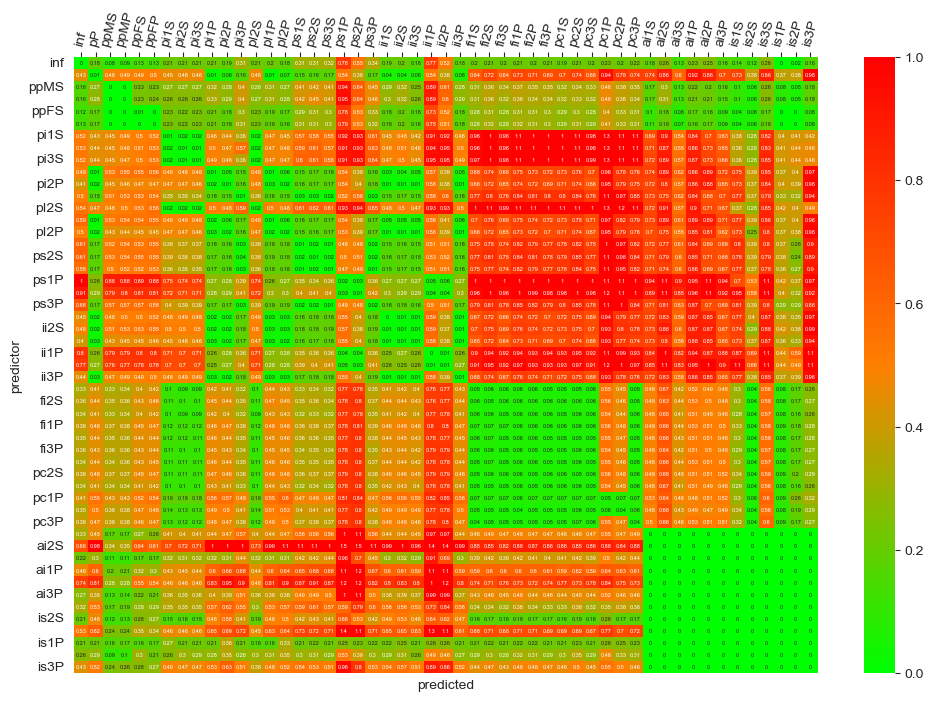

0 0.435118268066733


None

1.8620195743624923


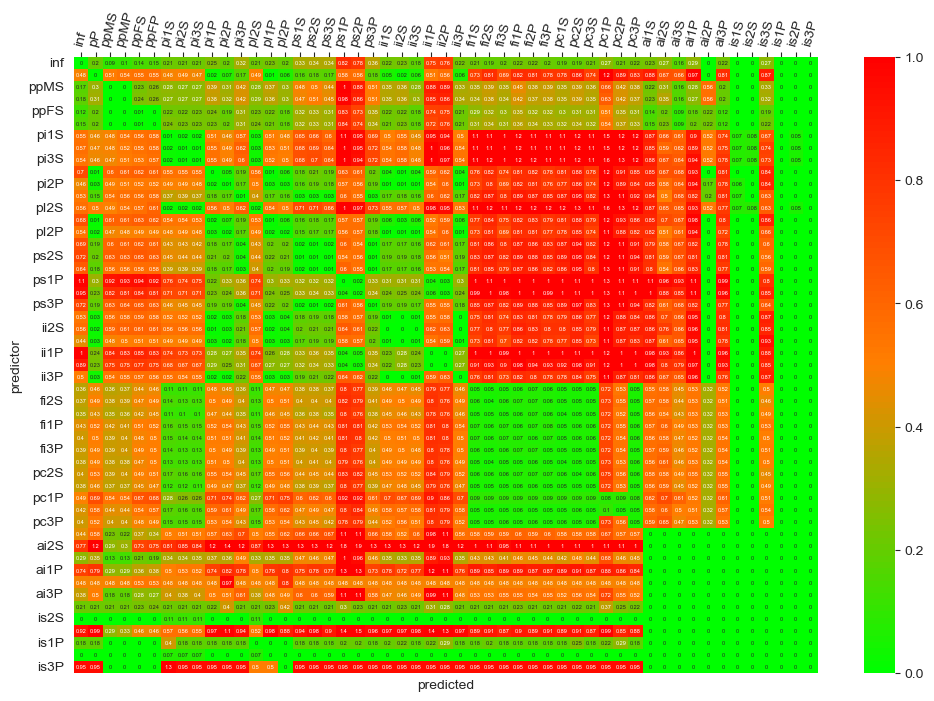

1 0.4266449198506602


None

2.0385505110797677


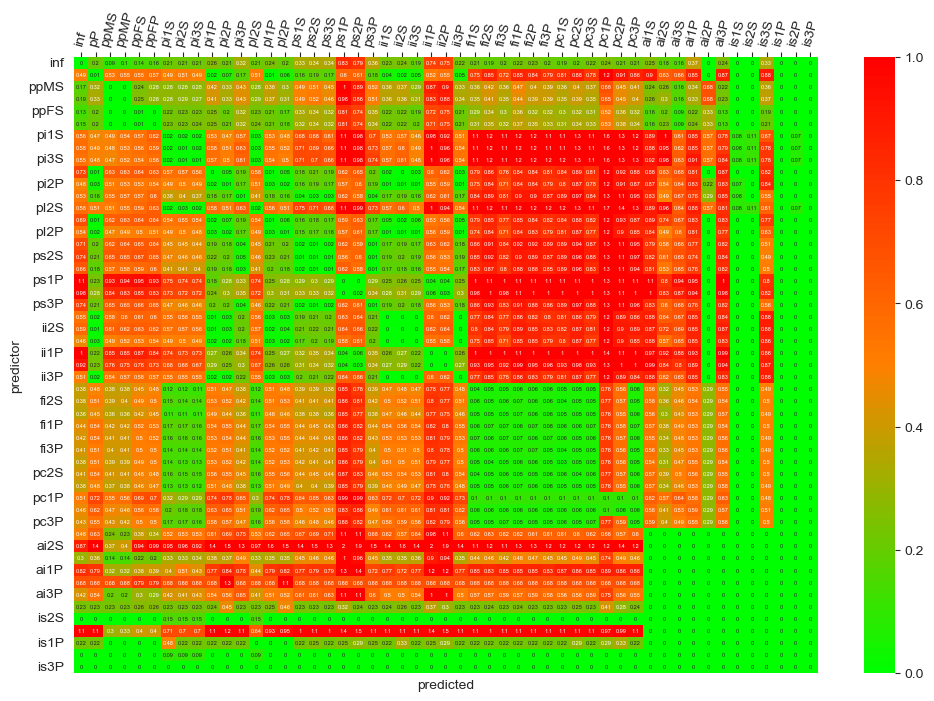

2 0.42975493100417955


None

1.894605532688999


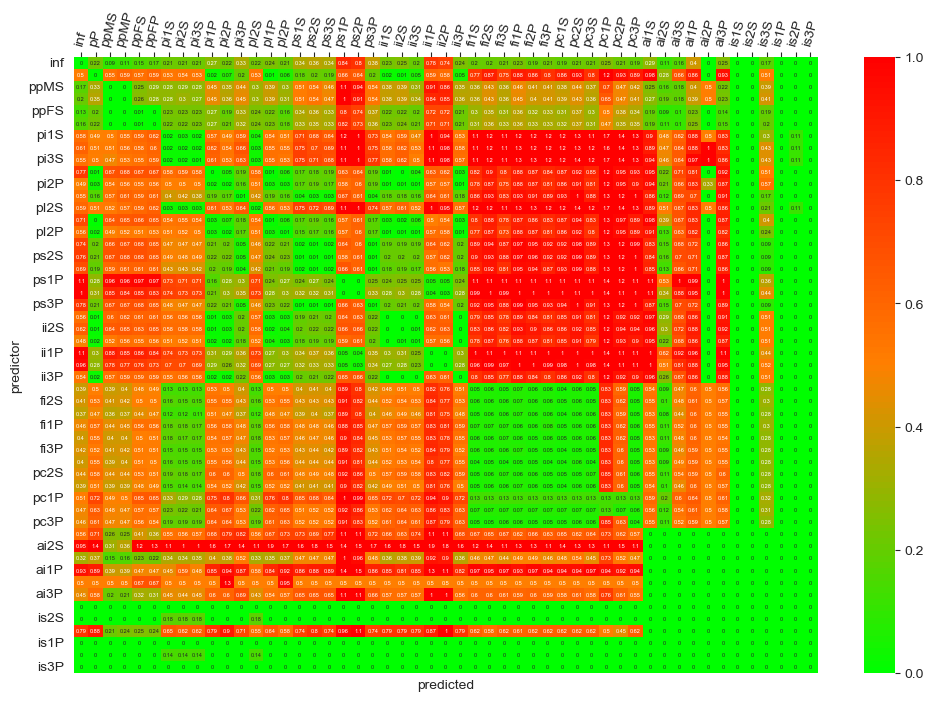

3 0.4219936655348269


None

2.1154746315049127


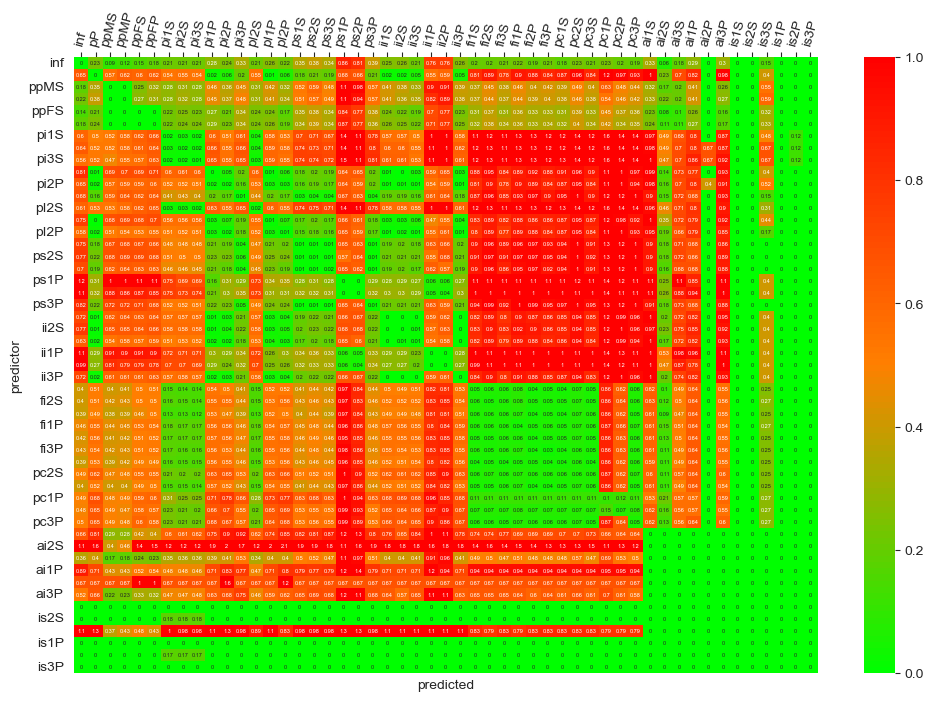

4 0.43770771195139885


None

2.3415907892459504


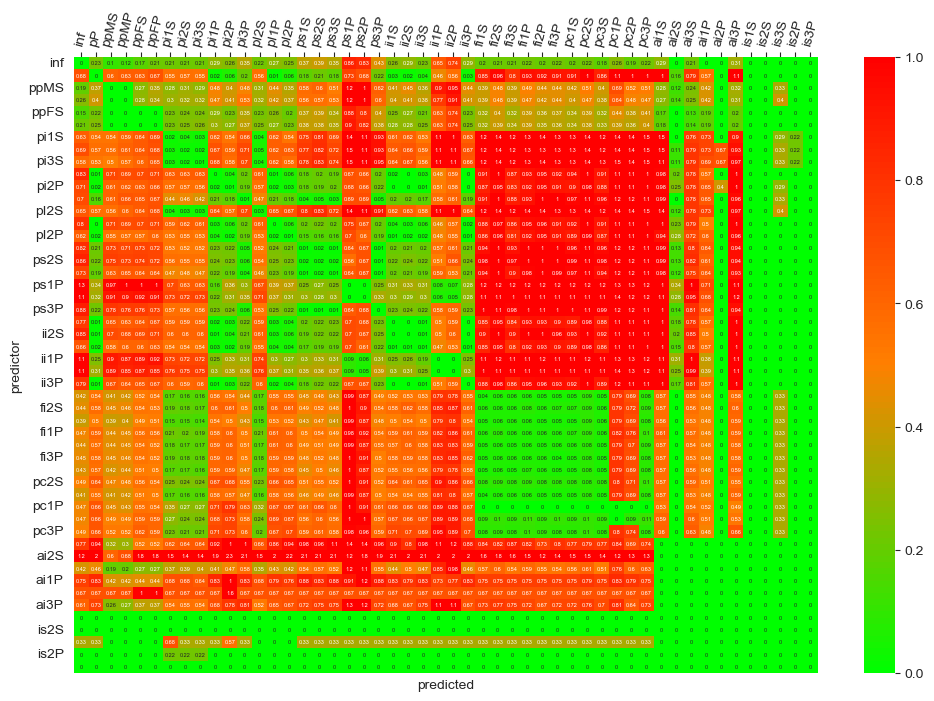

5 0.4595924468183653


None

1.6691902474868667


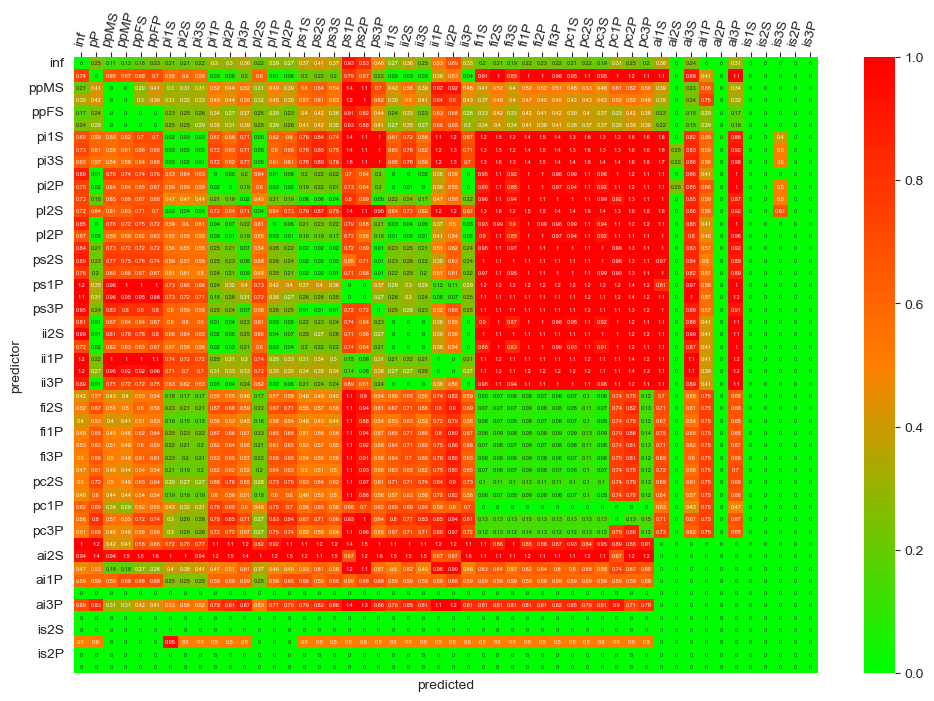

6 0.46080601378338387


None

1.7256406460506615


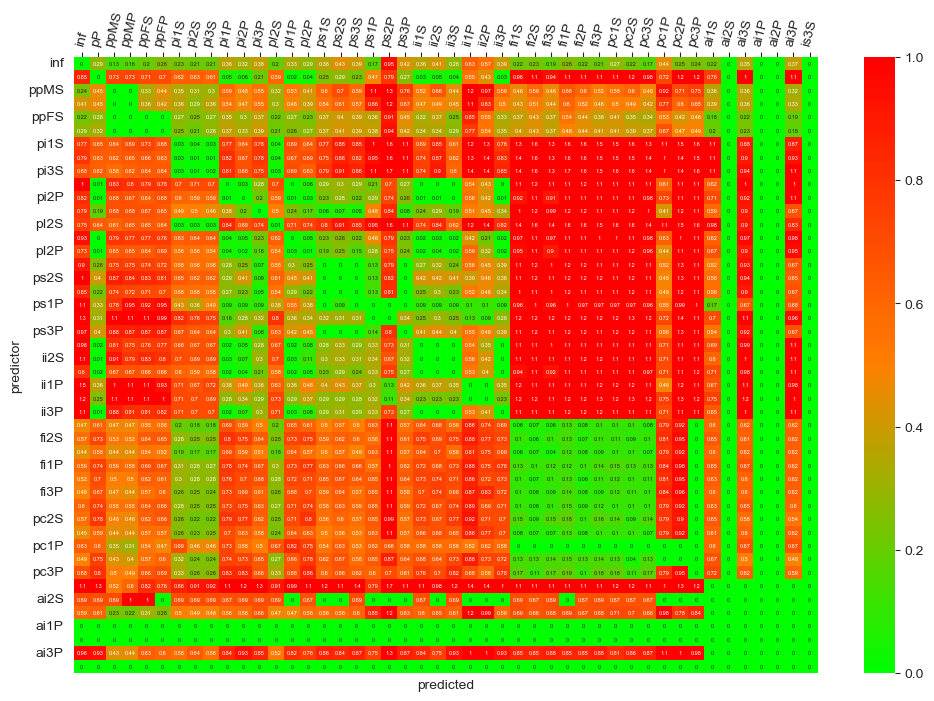

7 0.5101480998757024


None

1.7979860929809692


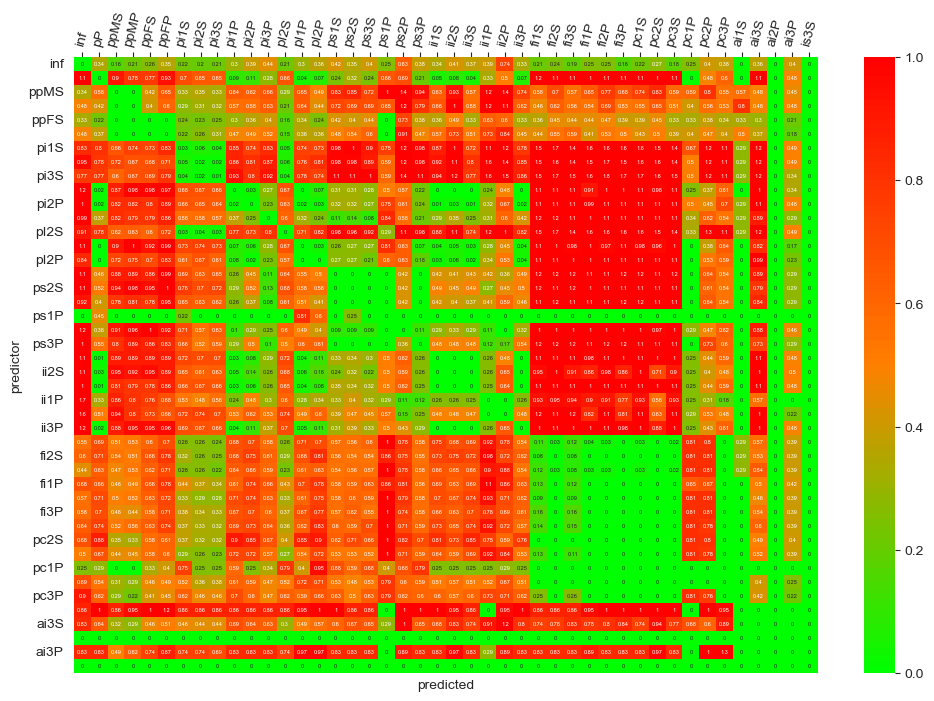

8 0.5007454872004329


{-1: 0.3544543256271373,
 0: 0.435118268066733,
 1: 0.4266449198506602,
 2: 0.42975493100417955,
 3: 0.4219936655348269,
 4: 0.43770771195139885,
 5: 0.4595924468183653,
 6: 0.46080601378338387,
 7: 0.5101480998757024,
 8: 0.5007454872004329}

In [112]:
tabLabels=["100%"]+["%d%%"%(k*10) for k in reversed(range(1,9))]
for i in range(9):
    # print(i)
    rulesFile="vlexique2-S%d-Regles.pkl"%i
    fRules=repFiles+rulesFile
    with open(fRules, 'rb') as input:
        regles = pickle.load(input)
    lEntropies=sampleEntropy(regles)
    dfE=makeTable(lEntropies)
    dfE.loc[:,"entropy"].round(decimals=4).to_csv(fRules.replace("Regles.pkl","Entropie.csv"),sep="\t",)
    with pd.ExcelWriter(repFiles+"entropies.xlsx",engine = "openpyxl",mode="a") as writer:
        dfE.loc[:,"entropy"].round(decimals=4).to_excel(writer, sheet_name=tabLabels[i])

    print(dfE.loc[:,"entropy"].max().max())

    plt.figure(figsize = (12,8))
    ax=sns.heatmap(dfE.loc[:,"entropy"].round(decimals=2),annot=True,annot_kws={"fontsize":4},cmap=cm,vmin=0,vmax=1)
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labelrotation=75)

    plt.savefig(repFiles+"HM-Entropy-%s.png"%tabLabels[i],dpi=300,bbox_inches="tight")
    plt.show()
    
    results[i]=dfE.loc[:,"entropy"].mean().mean()
    print(i,results[i])
results

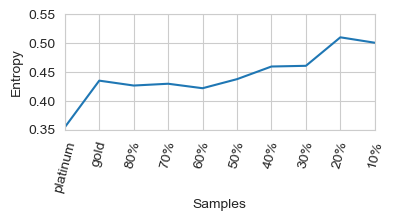

In [113]:
sGraphe=pd.Series(results).sort_index()
ax=sGraphe.plot(figsize=(4,1.5))
ax.set_xticks(range(-1,9))
ax.set_xticklabels(["platinum","gold"]+["%d%%"%(k*10) for k in reversed(range(1,9))])
ax.tick_params(axis='x', labelrotation=75)
ax.set_xlim(-1,8)
ax.set_ylim(.35,.55)
ax.set_yticks([.35,.4,.45,.5,.55])
ax.set_xlabel('Samples')
ax.set_ylabel('Entropy')
# ax.set_title("Inflectional system entropy")
plt.savefig(repFiles+"Entropy-Samples.png",dpi=300,bbox_inches="tight")

NameError: name 'repFiles' is not defined

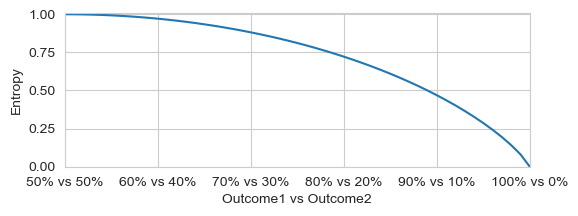

In [3]:
uncertainty={}
for i in reversed(range(51)):
    uncertainty["%d%% vs %d%%"%(100-i,i)]=entropy([100-i,i],base=2)
# uncertainty
ax=pd.Series(uncertainty).plot(figsize=(6,2))
ax.set_ylim(0,1.01)
ax.set_xlim(0,50)
ax.set_xlabel('Outcome1 vs Outcome2')
ax.set_ylabel('Entropy')
plt.savefig(repFiles+"Article/Entropy-2Outcomes.png",dpi=300,bbox_inches="tight")

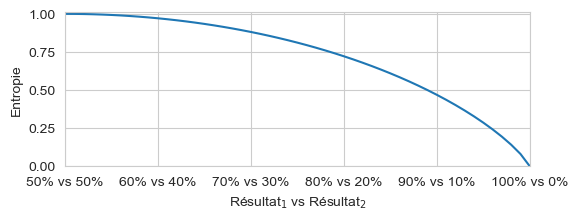

In [6]:
uncertainty={}
for i in reversed(range(51)):
    uncertainty["%d%% vs %d%%"%(100-i,i)]=entropy([100-i,i],base=2)
# uncertainty
ax=pd.Series(uncertainty).plot(figsize=(6,2))
ax.set_ylim(0,1.01)
ax.set_xlim(0,50)
ax.set_xlabel(u'Résultat$_1$ vs Résultat$_2$')
ax.set_ylabel('Entropie')
plt.savefig(repFiles+"Article/Entropie-2Resultats.png",dpi=300,bbox_inches="tight")

pour une classe de compétition Cc : 
- (Ri, Rj, Rk) => Ni, Nj, Nk
- Pi=Ni/(Ni+Nj+Nk)
- Ei=Pi\*log(Pi)+Pj\*log(Pj)+Pk\*log(Pk)


In [93]:
x=1.8
100-x,x,round(entropy([100-x,x],base=2),3)

(98.2, 1.8, 0.13)

In [2]:
def et(p):
    return -p*math.log(p,2)
def entropie(l):
    result=0
    t=sum(l)
    for x in l:
        result+=et(x/t)
    return result

In [17]:
c1=[327,37]
o=[4108,210,22,8,1]
t1=sum(c1)
t=t1+sum(o)
t1,entropie(c1),t,t1/t*entropie(c1)

(364, 0.4741990729840146, 4713, 0.03662390463954621)

In [16]:
c1=[22,327]
o=[4108,210,37,8,1]
t1=sum(c1)
t=t1+sum(o)
t1,entropie(c1),t,t1/t*entropie(c1)

(349, 0.3393854968460604, 4713, 0.02513166526613093)

In [ ]:
rulesFile="vlexique2-S4-Regles.pkl"
fRules=repFiles+rulesFile
with open(fRules, 'rb') as input:
    resultatsLecture = pickle.load(input)

In [31]:
for k,v in resultatsLecture[('ii1P', 'ii3S')].classeCF.items():
    print(k,v)
    t=sum(v.values())
    for kk,vv in v.items():
        print("\t",kk, round(vv/t*100))

jô-E, ô-E {'jô-E': 242, 'ô-E': 8}
	 jô-E 97
	 ô-E 3
jô-E, ô-E, Ejô-wajE {'ô-E': 4, 'Ejô-wajE': 1}
	 ô-E 80
	 Ejô-wajE 20
jô-E, ô-E, yjô-HE {'yjô-HE': 2}
	 yjô-HE 100
ô-E {'ô-E': 3}
	 ô-E 100
jô-E, ô-E, ijô-E {'ijô-E': 12, 'ô-E': 2}
	 ijô-E 86
	 ô-E 14
jô-E, ô-E, ujô-wE {'ujô-wE': 1}
	 ujô-wE 100


In [33]:
12.0/(242+8+4)*100

4.724409448818897